# Cats vs Dogs Image Classification using MobileNetV2 Transfer Learning

🐈 or 🐕

This capstone deep learning project focused on binary image classification.  
Aimed to classify images as either cats or dogs using a pretrained MobileNetV2 model.

The project includes the full development cycle:
- dataset loading
- data preprocessing
- model building
- training
- evaluation
- visualization of results
- model saving
- inference on new images

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib

from sklearn.metrics import classification_report, confusion_matrix

In [4]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU is available")
else:
    print("GPU is not available")

TensorFlow version: 2.20.0
GPU is available


# Dataset Loading

In [5]:
!wget -q https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip -O cats_and_dogs.zip
!unzip -q cats_and_dogs.zip -d cats_and_dogs

In [6]:
DATASET_DIR = "cats_and_dogs/PetImages"

print("Dataset folders:", os.listdir(DATASET_DIR))
print("Number of cat images:", len(os.listdir(os.path.join(DATASET_DIR, "Cat"))))
print("Number of dog images:", len(os.listdir(os.path.join(DATASET_DIR, "Dog"))))

Dataset folders: ['Cat', 'Dog']
Number of cat images: 12501
Number of dog images: 12501


# Removing Corrupted Images

In [7]:
import pathlib

data_dir = pathlib.Path(DATASET_DIR)

image_count = len(list(data_dir.glob('*/*.jpg')))
print("Total images:", image_count)

corrupted = 0

for image_path in data_dir.glob("*/*.jpg"):
    try:
        img = tf.io.read_file(str(image_path))
        tf.image.decode_jpeg(img)
    except:
        corrupted += 1
        image_path.unlink()

print("Removed corrupted images:", corrupted)

Total images: 25000
Removed corrupted images: 176



# Train and Validation Split



In [8]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 24824 files belonging to 2 classes.
Using 19860 files for training.
Found 24824 files belonging to 2 classes.
Using 4964 files for validation.


In [9]:
class_names = train_dataset.class_names
print(class_names)

['Cat', 'Dog']


# Data Visualization

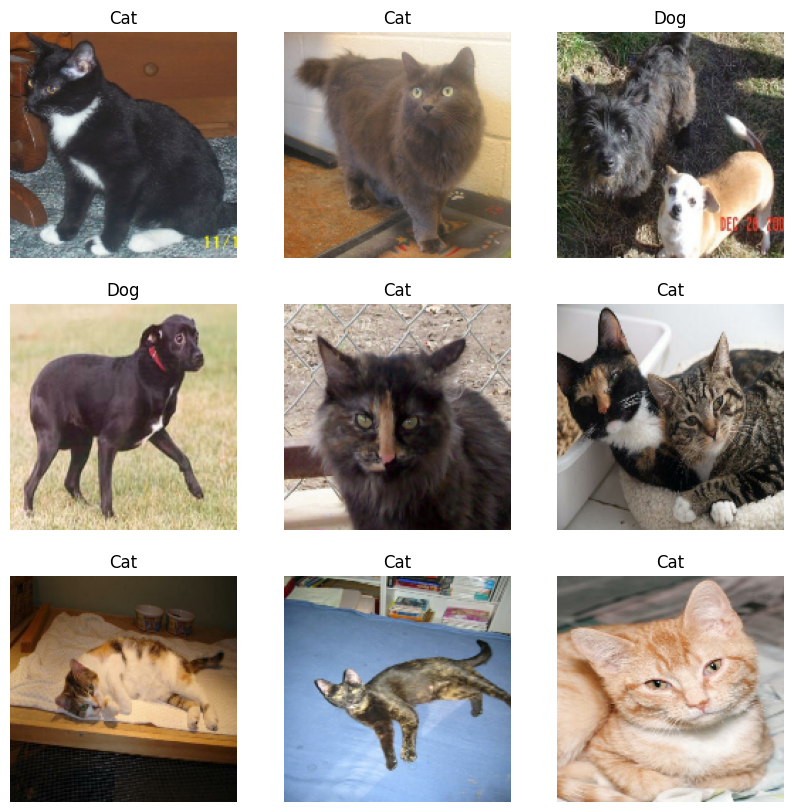

In [10]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


# Data Preprocessing

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

# Data Augmentation

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])


# Loading MobileNetV2

In [13]:
IMG_SHAPE = (160, 160, 3)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Freezing Base Model

In [14]:
base_model.trainable = False


# Building the Model

In [15]:
inputs = tf.keras.Input(shape=(160,160,3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

# Model Compilation

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


# Model Summary

In [18]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)


# Model Training

In [19]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.8255 - loss: 0.3814 - val_accuracy: 0.9633 - val_loss: 0.1383
Epoch 2/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.9191 - loss: 0.2039 - val_accuracy: 0.9736 - val_loss: 0.0915
Epoch 3/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.9308 - loss: 0.1726 - val_accuracy: 0.9768 - val_loss: 0.0758
Epoch 4/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.9354 - loss: 0.1611 - val_accuracy: 0.9788 - val_loss: 0.0680
Epoch 5/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.9393 - loss: 0.1502 - val_accuracy: 0.9797 - val_loss: 0.0632



# Training Results

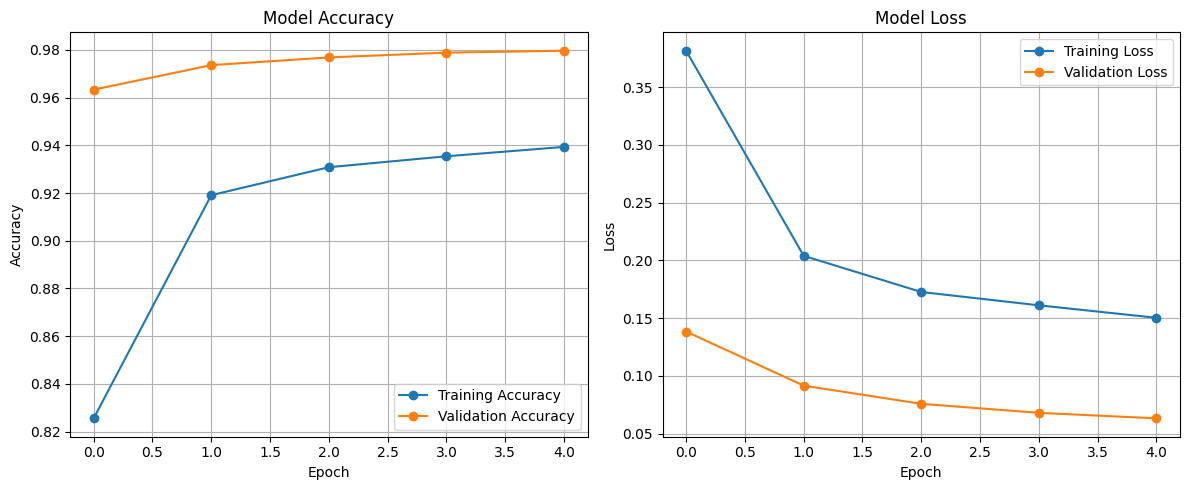

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Model Evaluation

In [21]:
loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9797 - loss: 0.0632
Validation Loss: 0.0632
Validation Accuracy: 0.9797



# Classification Report

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predictions = (predictions > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

cm = confusion_matrix(y_true, y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

         Cat       0.98      0.97      0.98      2449
         Dog       0.97      0.99      0.98      2515

    accuracy                           0.98      4964
   macro avg       0.98      0.98      0.98      4964
weighted avg       0.98      0.98      0.98      4964




# Confusion Matrix

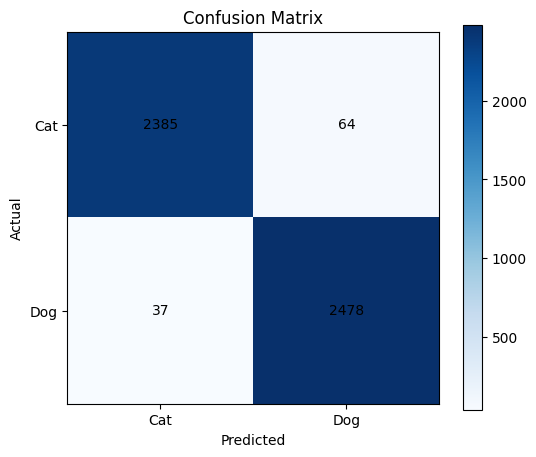

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")

plt.xticks([0,1], class_names)
plt.yticks([0,1], class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.colorbar()
plt.show()


# Prediction on New Image

In [33]:
from google.colab import files

uploaded = files.upload()

Saving IMG_0475.jpg to IMG_0475.jpg


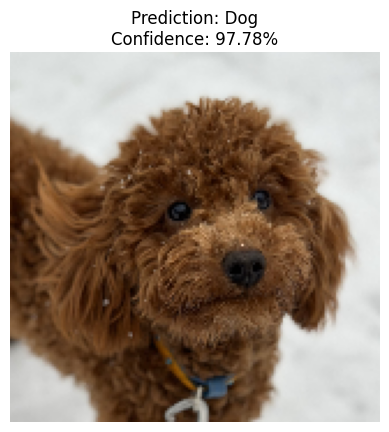

In [34]:
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(160,160))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)

if prediction[0][0] > 0.5:
    predicted_class = "Dog"
    confidence = prediction[0][0]
else:
    predicted_class = "Cat"
    confidence = 1 - prediction[0][0]

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}")
plt.show()


# Saving the Model

In [27]:
model.save("cats_vs_dogs_mobilenetv2.keras")
print("Model saved successfully.")

Model saved successfully.
